**PART-1**

In [1]:
from logging import warn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving time_series_60min_singleindex.csv to time_series_60min_singleindex.csv


In [99]:
df = pd.read_csv("time_series_60min_singleindex.csv")

In [101]:
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Columns: 300 entries, utc_timestamp to UA_load_forecast_entsoe_transparency
dtypes: float64(298), object(2)
memory usage: 115.4+ MB


In [103]:
df.shape
df.columns

Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='object', length=300)

In [104]:
de_columns = [col for col in df.columns if col.startswith("DE")]
de_columns

['DE_load_actual_entsoe_transparency',
 'DE_load_forecast_entsoe_transparency',
 'DE_solar_capacity',
 'DE_solar_generation_actual',
 'DE_solar_profile',
 'DE_wind_capacity',
 'DE_wind_generation_actual',
 'DE_wind_profile',
 'DE_wind_offshore_capacity',
 'DE_wind_offshore_generation_actual',
 'DE_wind_offshore_profile',
 'DE_wind_onshore_capacity',
 'DE_wind_onshore_generation_actual',
 'DE_wind_onshore_profile',
 'DE_50hertz_load_actual_entsoe_transparency',
 'DE_50hertz_load_forecast_entsoe_transparency',
 'DE_50hertz_solar_generation_actual',
 'DE_50hertz_wind_generation_actual',
 'DE_50hertz_wind_offshore_generation_actual',
 'DE_50hertz_wind_onshore_generation_actual',
 'DE_LU_load_actual_entsoe_transparency',
 'DE_LU_load_forecast_entsoe_transparency',
 'DE_LU_price_day_ahead',
 'DE_LU_solar_generation_actual',
 'DE_LU_wind_generation_actual',
 'DE_LU_wind_offshore_generation_actual',
 'DE_LU_wind_onshore_generation_actual',
 'DE_amprion_load_actual_entsoe_transparency',
 'DE_am

In [105]:
df = df[["utc_timestamp"] + de_columns]

In [106]:
df.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,NaN,NaN,37248.0,NaN,NaN,27913.0,NaN,NaN,667.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,...,13841.0,13362.0,NaN,3866.0,469.0,3398.0,5307.0,4703.0,NaN,5.0
2,2015-01-01T01:00:00Z,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,...,13267.0,12858.0,NaN,3974.0,466.0,3508.0,5087.0,4562.0,NaN,7.0
3,2015-01-01T02:00:00Z,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,667.0,...,12702.0,12611.0,NaN,4194.0,470.0,3724.0,4906.0,4517.0,NaN,8.0
4,2015-01-01T03:00:00Z,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,667.0,...,12452.0,12490.0,NaN,4446.0,473.0,3973.0,4865.0,4601.0,NaN,11.0


In [107]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df.set_index("utc_timestamp", inplace=True)
df = df.loc["2015-01-01":"2020-10-31"]
df.head()
df.tail()

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2020-09-30 19:00:00+00:00,57559.0,56708.0,NaN,0.0,NaN,NaN,10654.0,NaN,NaN,4754.0,...,17719.0,17190.0,0.0,8186.0,4628.0,3558.0,7657.0,7428.0,NaN,164.0
2020-09-30 20:00:00+00:00,54108.0,53270.0,NaN,0.0,NaN,NaN,11836.0,NaN,NaN,5194.0,...,16984.0,16446.0,0.0,8879.0,5056.0,3824.0,7072.0,6870.0,NaN,242.0
2020-09-30 21:00:00+00:00,49845.0,49239.0,NaN,0.0,NaN,NaN,12168.0,NaN,NaN,5339.0,...,15549.0,15256.0,0.0,8972.0,5165.0,3807.0,6465.0,6388.0,NaN,257.0
2020-09-30 22:00:00+00:00,46886.0,46620.0,NaN,0.0,NaN,NaN,12533.0,NaN,NaN,5399.0,...,14595.0,14586.0,0.0,9049.0,5123.0,3925.0,5963.0,5958.0,NaN,304.0
2020-09-30 23:00:00+00:00,45461.0,44986.0,NaN,0.0,NaN,NaN,12798.0,NaN,NaN,5381.0,...,14241.0,14062.0,0.0,9162.0,5124.0,4038.0,5668.0,5735.0,NaN,342.0


In [108]:
df.isnull().sum()
df.describe()

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
count,50400.000000,50376.000000,43799.000000,50297.000000,43696.000000,43799.000000,50326.000000,43725.000000,43799.000000,50326.000000,...,50400.000000,50400.000000,50393.000000,50400.000000,50400.000000,50400.000000,50400.000000,50376.000000,50386.000000,50400.000000
mean,55492.468552,54791.384231,42378.132240,4566.042905,0.101902,39972.882098,11552.234650,0.278908,3261.083312,1970.480984,...,17184.740813,17220.725794,1692.740420,5725.275119,1715.408591,4009.865774,6960.462103,6950.349432,640.991684,248.046766
std,10015.431042,9496.890313,4306.371168,6940.267590,0.155718,7262.640092,9076.350769,0.211566,1359.147670,1567.541202,...,3231.802463,3131.109997,2597.879404,4365.844293,1402.580617,3277.980085,1542.315045,1549.373834,994.208084,291.052823
min,31307.000000,28824.000000,37248.000000,0.000000,0.000000,27913.000000,135.000000,0.003800,667.000000,0.000000,...,9495.000000,9614.000000,0.000000,20.000000,0.000000,0.000000,3452.000000,3410.000000,0.000000,0.000000
25%,47106.000000,46987.000000,38810.000000,0.000000,0.000000,33737.000000,4506.000000,0.114900,2219.000000,586.000000,...,14507.000000,14776.000000,0.000000,2094.000000,457.000000,1433.000000,5649.000000,5626.000000,0.000000,42.000000
50%,55092.000000,54731.500000,40941.000000,173.000000,0.003000,39808.000000,9015.000000,0.221100,3115.000000,1640.000000,...,17010.000000,17175.000000,56.000000,4675.000000,1424.000000,3100.000000,6827.000000,6823.000000,17.000000,132.000000
75%,64309.250000,62877.250000,46092.000000,7342.000000,0.162300,47730.000000,16113.750000,0.389300,4486.000000,3066.000000,...,19932.000000,19699.000000,2694.000000,8495.250000,2723.000000,5724.000000,8348.000000,8326.000000,989.750000,341.000000
max,77549.000000,75912.000000,50508.000000,32947.000000,0.687300,50452.000000,46064.000000,1.078000,5742.000000,6901.000000,...,24577.000000,25417.000000,12301.000000,20631.000000,6080.000000,15874.000000,11733.000000,10956.000000,4453.000000,1474.000000


In [109]:
daily_df = df.resample("D").mean()
weekly_df = df.resample("W").mean()
daily_df.head()
weekly_df.head()

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-04 00:00:00+00:00,47233.739583,46208.833333,37249.541667,585.101124,0.015706,27923.020833,18507.260417,0.662779,667.031250,483.906250,...,15670.187500,15203.677083,153.887640,7790.385417,439.531250,7350.885417,5700.385417,5699.916667,53.797753,139.531250
2015-01-11 00:00:00+00:00,56191.101190,53819.654762,37257.065476,787.077381,0.021127,27961.363095,17309.958333,0.618949,674.315476,372.244048,...,18350.636905,17692.565476,264.755952,6842.952381,338.613095,6504.339286,6824.029762,5801.363095,179.577381,229.803571
2015-01-18 00:00:00+00:00,57672.678571,57965.303571,37268.958333,1024.113095,0.027482,27994.238095,15602.815476,0.557486,675.619048,408.029762,...,18956.583333,19320.690476,369.511905,6349.732143,369.244048,5980.470238,7666.214286,7075.898810,171.821429,187.708333
2015-01-25 00:00:00+00:00,58613.303571,57810.392857,37296.648810,578.154762,0.015504,28049.547619,2787.720238,0.099351,692.839286,181.690476,...,19298.696429,19284.196429,230.136905,1209.208333,170.827381,1038.422619,7958.250000,7666.202381,75.154762,22.178571
2015-02-01 00:00:00+00:00,58734.029762,58438.255952,37338.702381,779.095238,0.020862,28121.946429,10045.607143,0.357323,712.904762,355.267857,...,19271.250000,19103.023810,271.250000,3917.696429,321.119048,3596.625000,7892.077381,7964.410714,96.738095,125.452381


In [110]:
daily_df.columns

Index(['DE_load_actual_entsoe_transparency',
       'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity',
       'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity',
       'DE_wind_generation_actual', 'DE_wind_profile',
       'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual',
       'DE_wind_offshore_profile', 'DE_wind_onshore_capacity',
       'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile',
       'DE_50hertz_load_actual_entsoe_transparency',
       'DE_50hertz_load_forecast_entsoe_transparency',
       'DE_50hertz_solar_generation_actual',
       'DE_50hertz_wind_generation_actual',
       'DE_50hertz_wind_offshore_generation_actual',
       'DE_50hertz_wind_onshore_generation_actual',
       'DE_LU_load_actual_entsoe_transparency',
       'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead',
       'DE_LU_solar_generation_actual', 'DE_LU_wind_generation_actual',
       'DE_LU_wind_offshore_generation_actual',
  

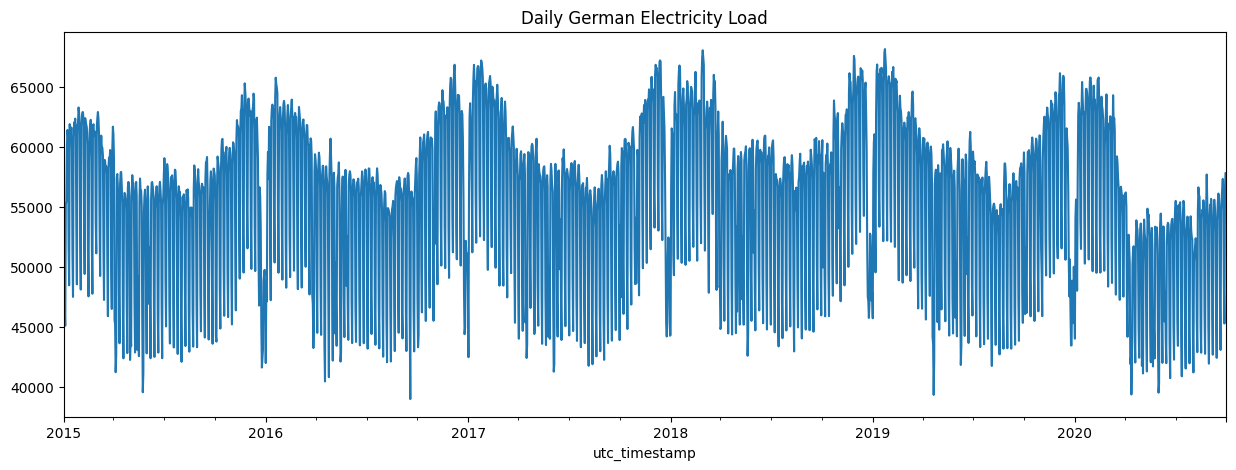

In [111]:
daily_df["DE_load_actual_entsoe_transparency"].plot(figsize=(15,5))
plt.title("Daily German Electricity Load")
plt.show()

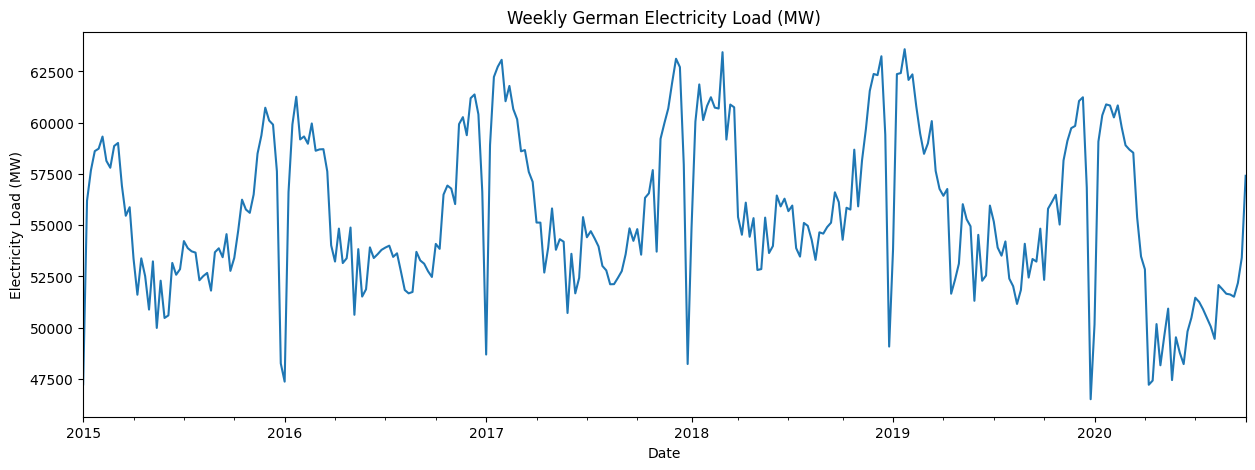

In [112]:
weekly_df["DE_load_actual_entsoe_transparency"].plot(figsize=(15,5))
plt.title("Weekly German Electricity Load (MW)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.show()

In [113]:
daily_df.describe()

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
count,2100.000000,2100.000000,1825.000000,2099.000000,1824.000000,1825.000000,2100.000000,1825.000000,1825.000000,2100.000000,...,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,55492.468552,54787.503954,42378.317854,4559.540729,0.101737,39973.121347,11553.688842,0.279032,3261.139954,1971.457487,...,17184.740813,17220.725794,1692.533438,5725.275119,1715.408591,4009.865774,6960.462103,6949.703167,640.972593,248.046766
std,6601.474342,6006.255414,4307.626921,2906.179929,0.065391,7264.635625,8410.328900,0.194715,1359.539724,1405.487398,...,2112.544981,2014.079384,1090.773679,3970.240086,1235.734716,2966.287837,1117.729231,1130.815143,412.253363,260.131740
min,38952.666667,36266.333333,37248.083333,0.000000,0.000000,27913.541667,686.750000,0.016754,667.000000,7.500000,...,11805.291667,12038.791667,63.791667,152.125000,2.958333,109.125000,4256.583333,4289.041667,0.000000,2.166667
25%,50413.447917,50976.281250,38810.000000,1758.645833,0.039377,33737.000000,5182.802083,0.129263,2219.000000,761.145833,...,15610.364583,15727.041667,642.447917,2480.875000,655.208333,1725.333333,5996.822917,5998.083333,256.125000,69.395833
50%,56776.916667,55545.250000,40941.000000,4498.166667,0.100785,39808.000000,9113.437500,0.225483,3115.000000,1759.041667,...,17545.333333,17314.666667,1643.187500,4873.000000,1527.354167,3232.416667,7264.104167,7248.770833,613.479167,149.833333
75%,60430.093750,58932.687500,46092.583333,6919.020833,0.155578,47730.000000,15793.968750,0.376462,4486.000000,2906.427083,...,18770.927083,18722.010417,2597.239583,8016.197917,2577.645833,5445.062500,7796.375000,7773.520833,997.541667,329.375000
max,68183.583333,68535.458333,50508.000000,12101.208333,0.247487,50452.000000,43086.875000,0.955900,5742.000000,6090.458333,...,21362.625000,22553.166667,4404.541667,18755.666667,5624.458333,14817.375000,9545.541667,9484.875000,1571.791667,1326.375000


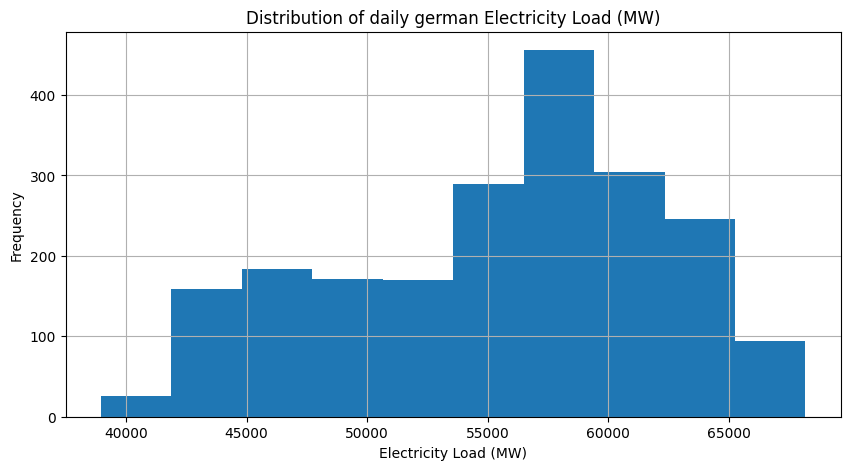

In [114]:
daily_df['DE_load_actual_entsoe_transparency'].hist(figsize=(10,5))
plt.title("Distribution of daily german Electricity Load (MW)")
plt.xlabel("Electricity Load (MW)")
plt.ylabel("Frequency")
plt.show()

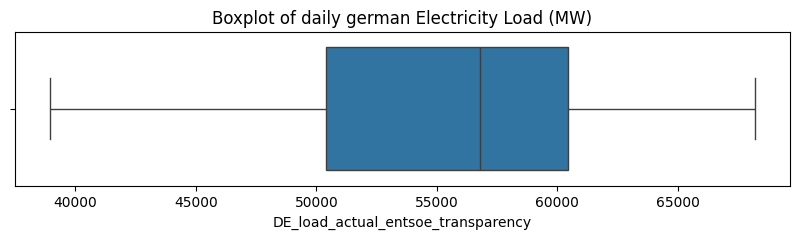

In [115]:
plt.figure(figsize=(10,2))

sns.boxplot(x=daily_df["DE_load_actual_entsoe_transparency"])

plt.title("Boxplot of daily german Electricity Load (MW)")
plt.show()

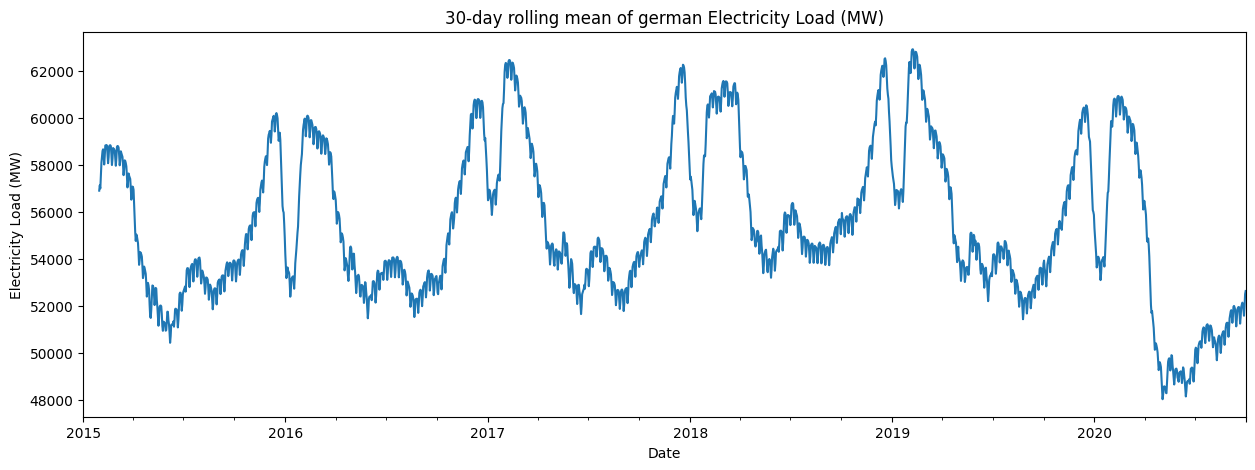

In [116]:
daily_df["DE_load_actual_entsoe_transparency"].rolling(30).mean().plot(figsize=(15,5))

plt.title("30-day rolling mean of german Electricity Load (MW)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.show()

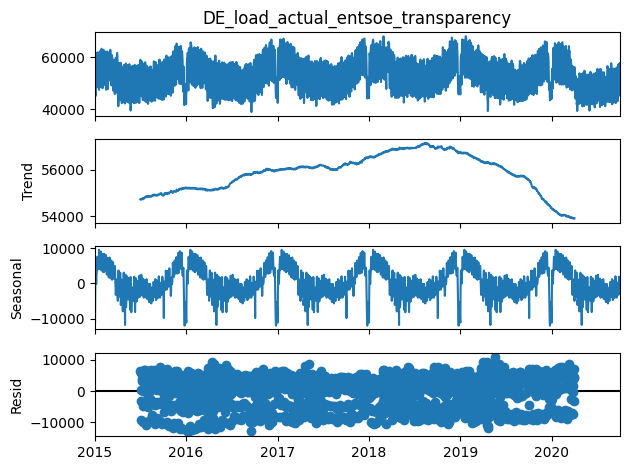

In [117]:
decomposition = seasonal_decompose(
    daily_df["DE_load_actual_entsoe_transparency"].dropna(),
    model="addictive",
    period=365
)

decomposition.plot()
plt.show()

<Axes: xlabel='utc_timestamp'>

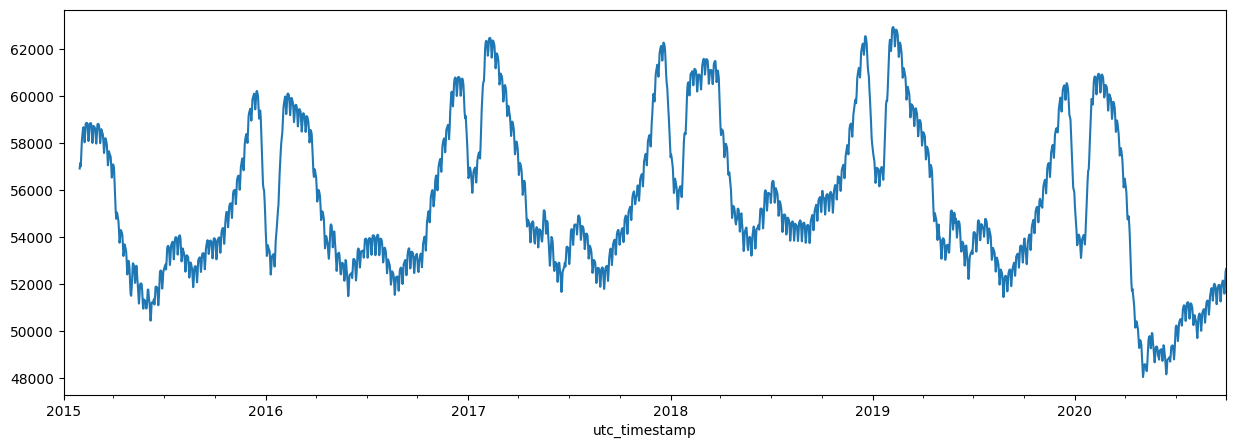

In [118]:
daily_df['DE_load_actual_entsoe_transparency'].rolling(30).mean().plot(figsize=(15,5))

In [119]:
result = adfuller(daily_df["DE_load_actual_entsoe_transparency"].dropna())

print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

ADF Statistics:  -4.593460971848512
p-value:  0.0001328022126933878


In [120]:
result = kpss(daily_df["DE_load_actual_entsoe_transparency"].dropna())

print("KPSS Statistic:", result[0])
print("p-value:", result[1])

KPSS Statistic: 0.5394547646749068
p-value: 0.03278045840655251


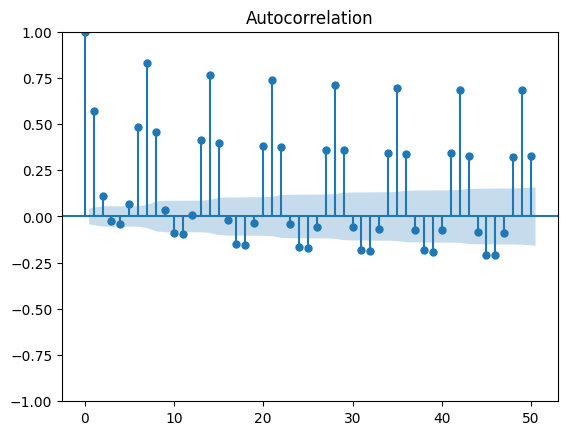

In [121]:
plot_acf(daily_df["DE_load_actual_entsoe_transparency"].dropna(), lags=50)
plt.show()

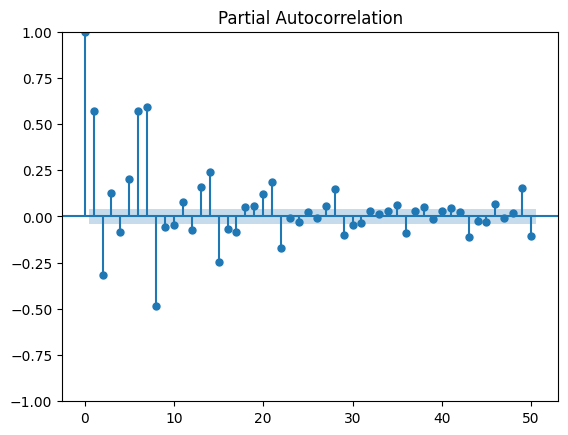

In [122]:
plot_pacf(daily_df["DE_load_actual_entsoe_transparency"].dropna(), lags=50)
plt.show()

**PART-2**

In [123]:
series = daily_df['DE_load_actual_entsoe_transparency'].dropna()

train = series.loc[:'2018-10-31']
test = series.loc['2018-11-01':]

print("Training observations: ", len(train))
print("Testing observations: ", len(test))

Training observations:  1400
Testing observations:  700


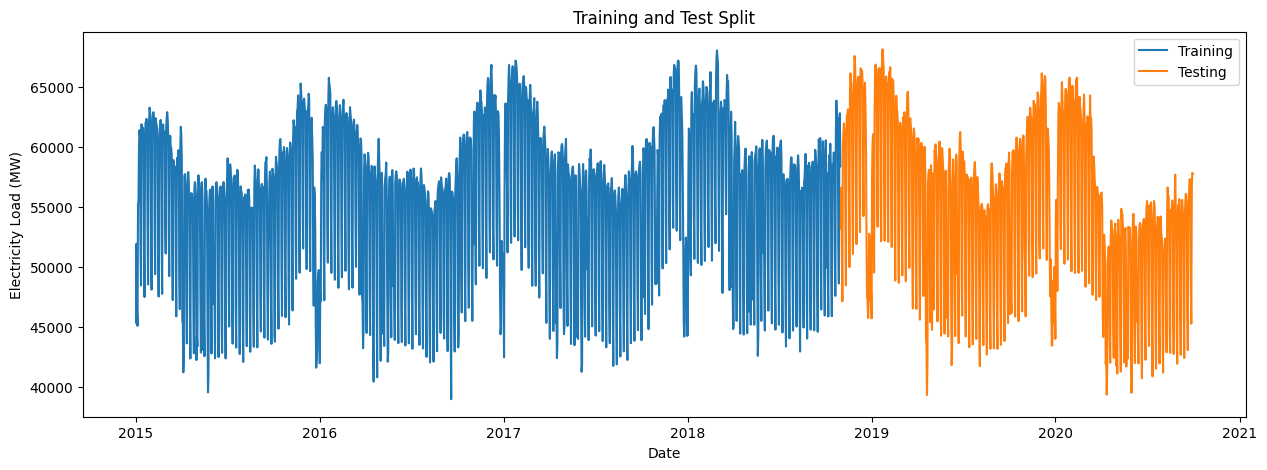

In [124]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Training")
plt.plot(test, label="Testing")

plt.title("Training and Test Split")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend()
plt.show()

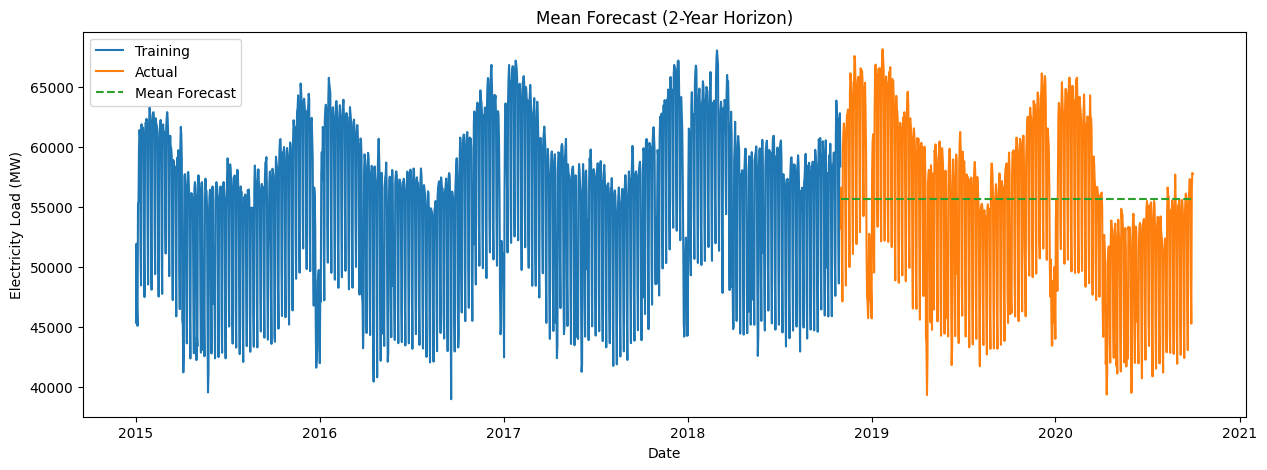

In [125]:
# Mean Forecast

mean_forecast = np.repeat(train.mean(), len(test))

mean_forecast = pd.Series(
    mean_forecast,
    index=test.index
)

plt.figure(figsize=(15,5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(mean_forecast, label="Mean Forecast", linestyle="--")

plt.title("Mean Forecast (2-Year Horizon)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend()
plt.show()

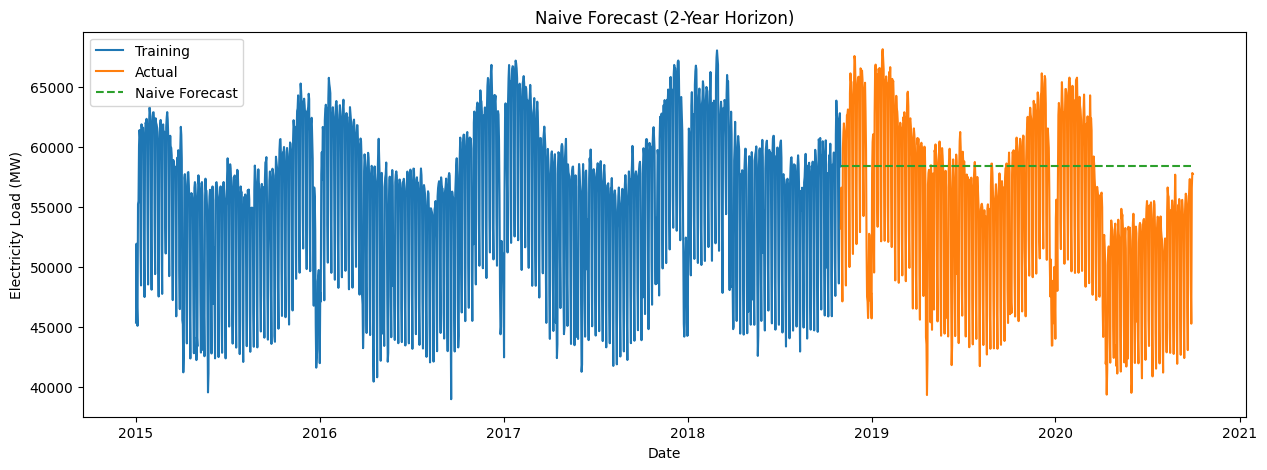

In [126]:
# Naive Forecast

naive_forecast = np.repeat(train.iloc[-1], len(test))

naive_forecast = pd.Series(
    naive_forecast,
    index=test.index
)

plt.figure(figsize=(15,5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(naive_forecast, label="Naive Forecast", linestyle="--")

plt.title("Naive Forecast (2-Year Horizon)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend()
plt.show()

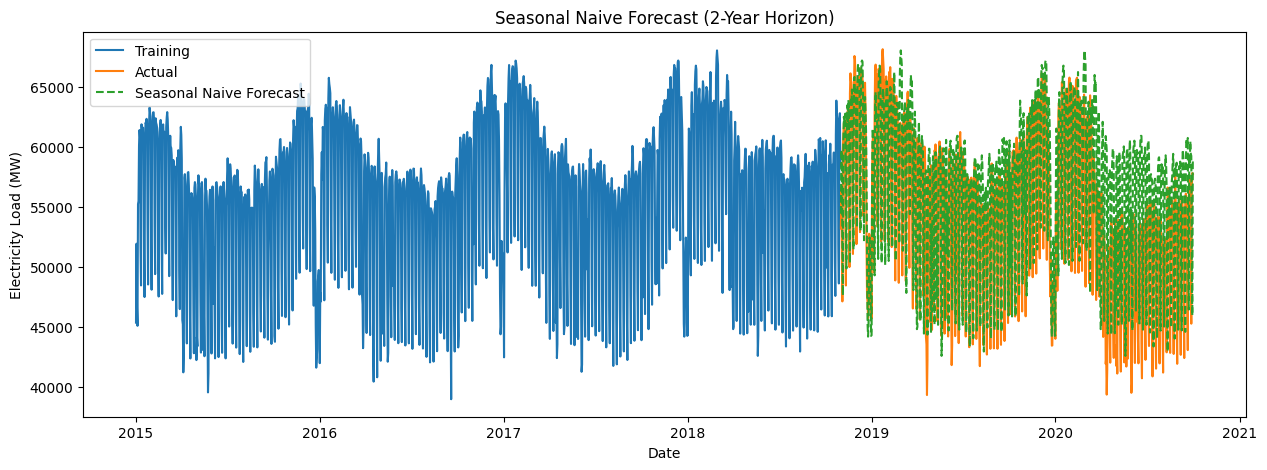

In [130]:
# Seasonal Naive Forecast (365-day seasonality)

season_length = 365

seasonal_naive_forecast = train.iloc[-season_length:].values

forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test) / season_length))
)[:len(test)]

seasonal_naive_forecast = pd.Series(
    forecast,
    index=test.index
)

plt.figure(figsize=(15,5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(
    seasonal_naive_forecast,
    label="Seasonal Naive Forecast",
    linestyle="--"
)

plt.title("Seasonal Naive Forecast (2-Year Horizon)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend()
plt.savefig(
    "seasonal_naive_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

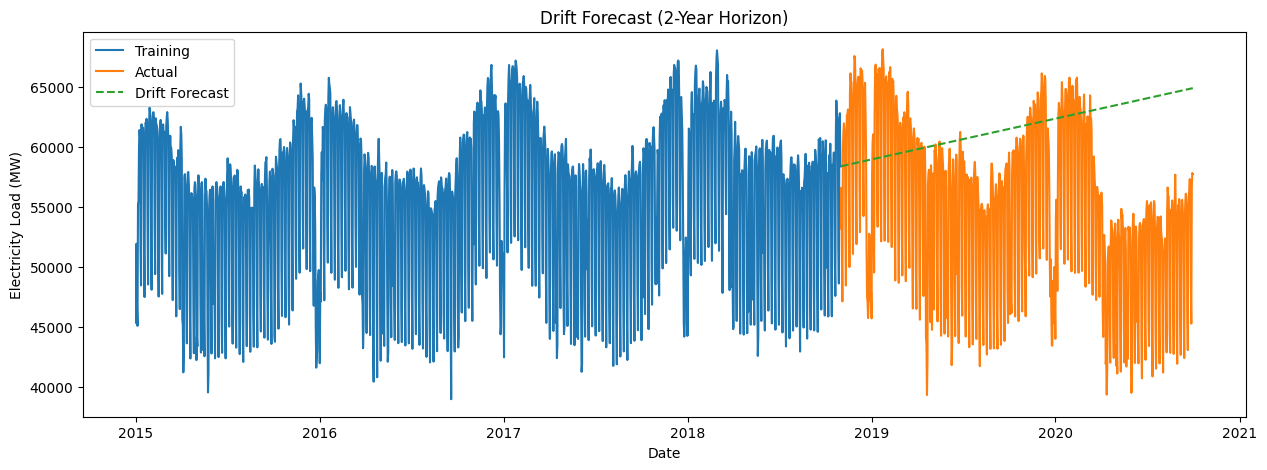

In [131]:
# Drift Forecast

n = len(train)

drift = (train.iloc[-1] - train.iloc[0]) / (n - 1)

forecast = [
    train.iloc[-1] + drift * (i + 1)
    for i in range(len(test))
]

drift_forecast = pd.Series(
    forecast,
    index=test.index
)

plt.figure(figsize=(15,5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(
    drift_forecast,
    label="Drift Forecast",
    linestyle="--"
)

plt.title("Drift Forecast (2-Year Horizon)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend()
plt.show()

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, y_train, seasonality=365):
    naive_errors = np.abs(
        y_train.iloc[seasonality:].values -
        y_train.iloc[:-seasonality].values
    )

    scale = naive_errors.mean()

    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(name, y_true, y_pred, y_train):

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true)
    }

In [133]:
results = []

results.append(
    evaluate_forecast(
        "Mean",
        test,
        mean_forecast,
        train
    )
)

results.append(
    evaluate_forecast(
        "Naive",
        test,
        naive_forecast,
        train
    )
)

results.append(
    evaluate_forecast(
        "Seasonal Naive",
        test,
        seasonal_naive_forecast,
        train
    )
)

results.append(
    evaluate_forecast(
        "Drift",
        test,
        drift_forecast,
        train
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,MASE,Bias
0,Mean,5678.915345,6901.720147,1.248690,614.201131
1,Naive,6152.979226,7633.155407,1.352928,3317.915536
2,Seasonal Naive,6235.269405,8018.999990,1.371022,1896.027143
3,Drift,8160.386373,10159.839942,1.794320,6588.507700


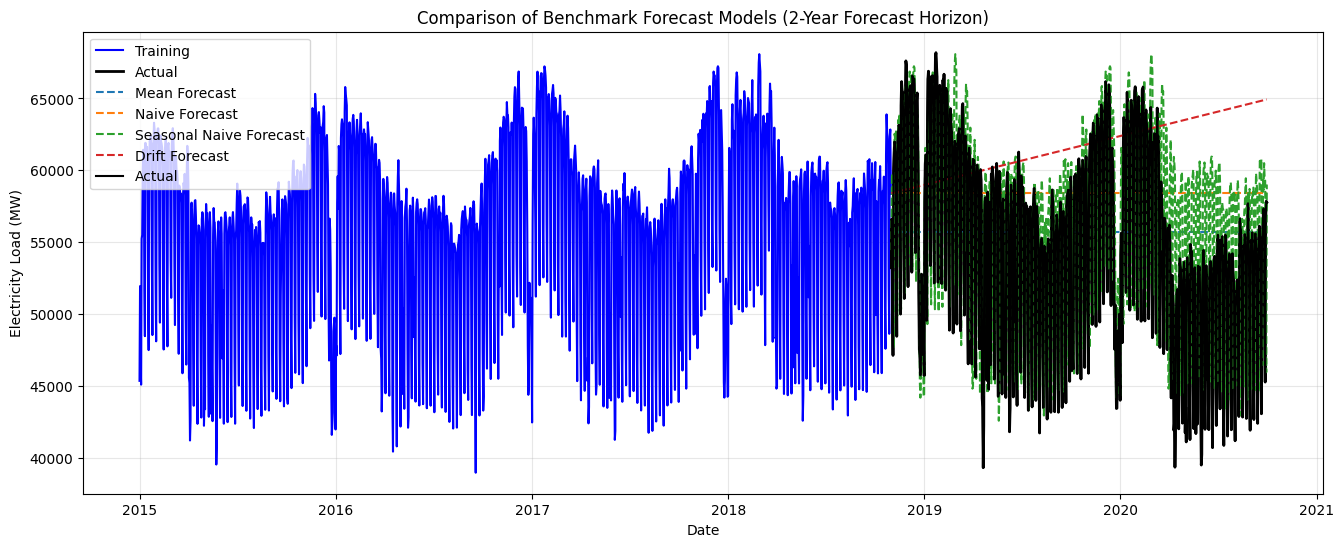

In [134]:
plt.figure(figsize=(16,6))

# Training and actual test data
plt.plot(train, label="Training", color="blue")
plt.plot(test, label="Actual", color="black", linewidth=2)

# Benchmark forecasts
plt.plot(mean_forecast, label="Mean Forecast", linestyle="--")
plt.plot(naive_forecast, label="Naive Forecast", linestyle="--")
plt.plot(seasonal_naive_forecast, label="Seasonal Naive Forecast", linestyle="--")
plt.plot(drift_forecast, label="Drift Forecast", linestyle="--")
plt.plot(
    test,
    label="Actual",
    color="black",
    linewidth=1.5
)

plt.title("Comparison of Benchmark Forecast Models (2-Year Forecast Horizon)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")

plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.show()

**PART-3**

In [135]:
!pip install pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
import itertools
import warnings

In [136]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,              # weekly seasonality
    start_p=0,
    max_p=6,
    start_q=0,
    max_q=6,
    start_P=0,
    max_P=2,
    start_Q=0,
    max_Q=2,
    max_d=2,
    max_D=1,
    information_criterion="aic",
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=28417.779, Time=0.18 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=26725.358, Time=6.12 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=27691.507, Time=4.83 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=28415.782, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=28417.809, Time=0.19 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=inf, Time=31.92 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=27001.193, Time=4.74 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=27827.303, Time=0.67 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=27175.789, Time=8.88 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=26765.423, Time=1.62 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=26659.579, Time=2.88 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=28204.533, Time=0.23 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=26382.253, Time=12.88 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=27071.317, Time=10.92 sec
 ARIMA(2,1,0)(1,0,1)[7

In [137]:
print(auto_model.summary())
print(auto_model.order)
print(auto_model.seasonal_order)

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1400
Model:             SARIMAX(2, 1, 0)x(2, 0, 0, 7)   Log Likelihood              -13185.128
Date:                           Thu, 16 Jul 2026   AIC                          26380.256
Time:                                   22:58:03   BIC                          26406.473
Sample:                               01-01-2015   HQIC                         26390.057
                                    - 10-31-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2291      0.014    -16.352      0.000      -0.257      -0.202
ar.L2         -0.2138      0.016    -13.643

In [138]:
best_order = auto_model.order

print("Best ARIMA Order:", best_order)

Best ARIMA Order: (2, 1, 0)


In [139]:
sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)

In [140]:
print(sarima_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:     DE_load_actual_entsoe_transparency   No. Observations:                 1400
Model:                SARIMAX(2, 1, 0)x(1, 1, [1], 7)   Log Likelihood              -12785.138
Date:                                Thu, 16 Jul 2026   AIC                          25580.276
Time:                                        22:59:04   BIC                          25606.436
Sample:                                    01-01-2015   HQIC                         25590.061
                                         - 10-31-2018                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2964      0.013    -22.332      0.000      -0.322      -0.270
ar.

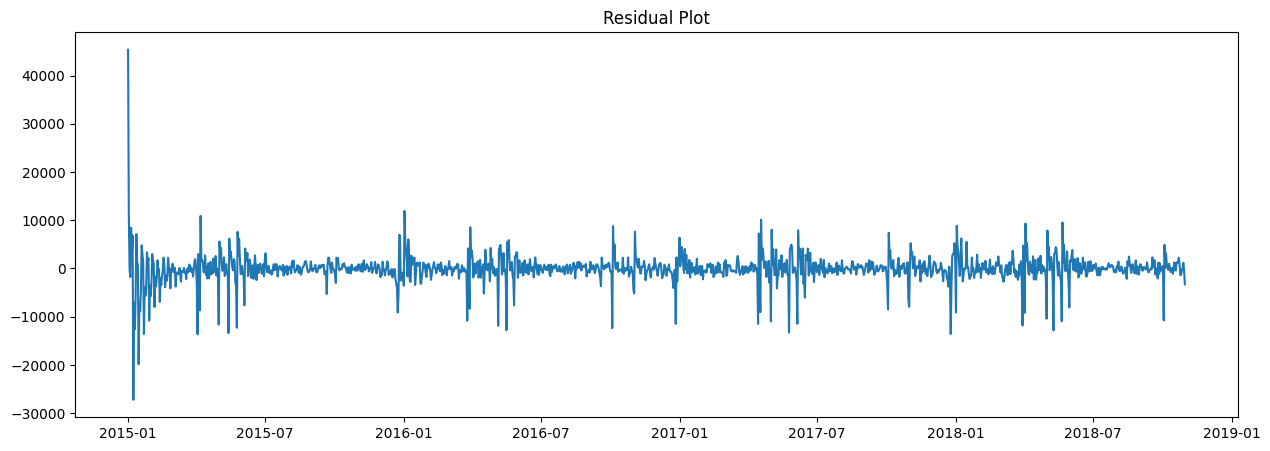

In [141]:
residuals = sarima_fit.resid

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("Residual Plot")

plt.show()

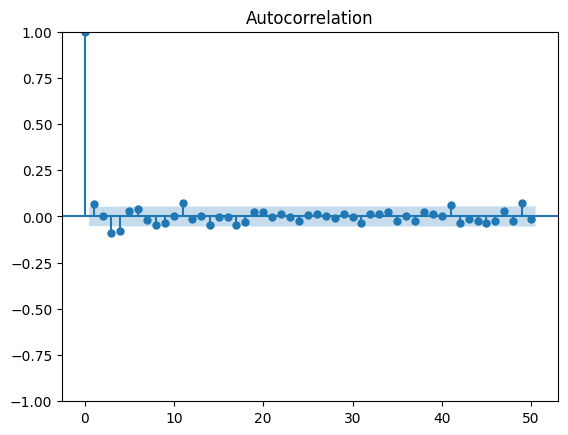

In [142]:
plot_acf(
    residuals.dropna(),
    lags=50
)

plt.show()

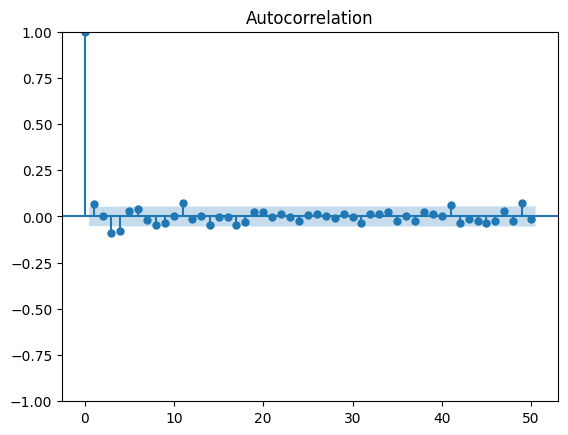

In [143]:
plot_acf(
    residuals.dropna(),
    lags=50
)

plt.show()

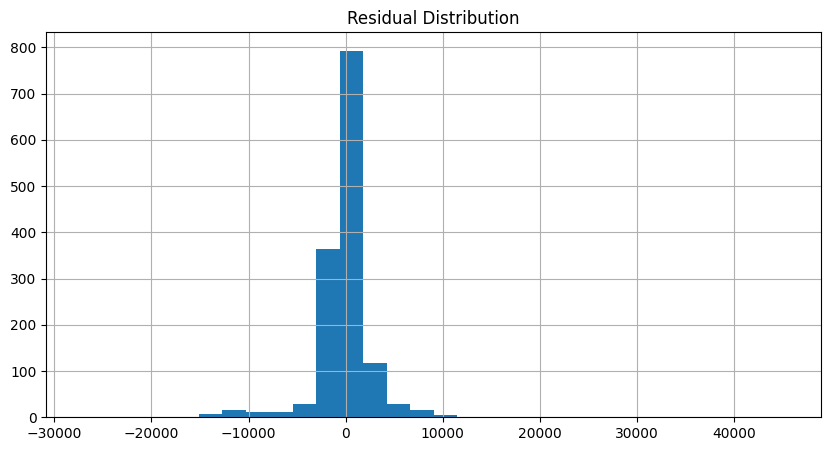

In [144]:
plt.figure(figsize=(10,5))

residuals.hist(bins=30)

plt.title("Residual Distribution")

plt.show()

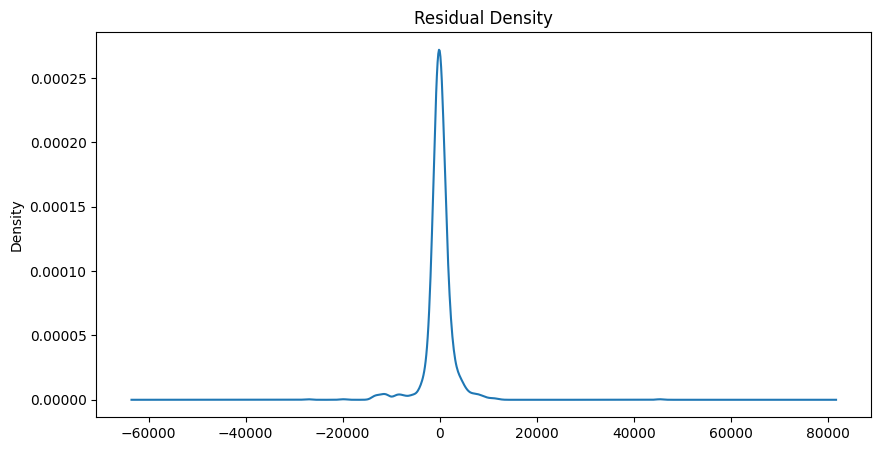

In [145]:
plt.figure(figsize=(10,5))

residuals.plot(kind="kde")

plt.title("Residual Density")

plt.show()

In [148]:
forecast = sarima_fit.get_forecast(
    steps=len(test)
)

forecast_mean = forecast.predicted_mean

confidence = forecast.conf_int()

# Align forecast with test dates
forecast_mean.index = test.index
confidence.index = test.index

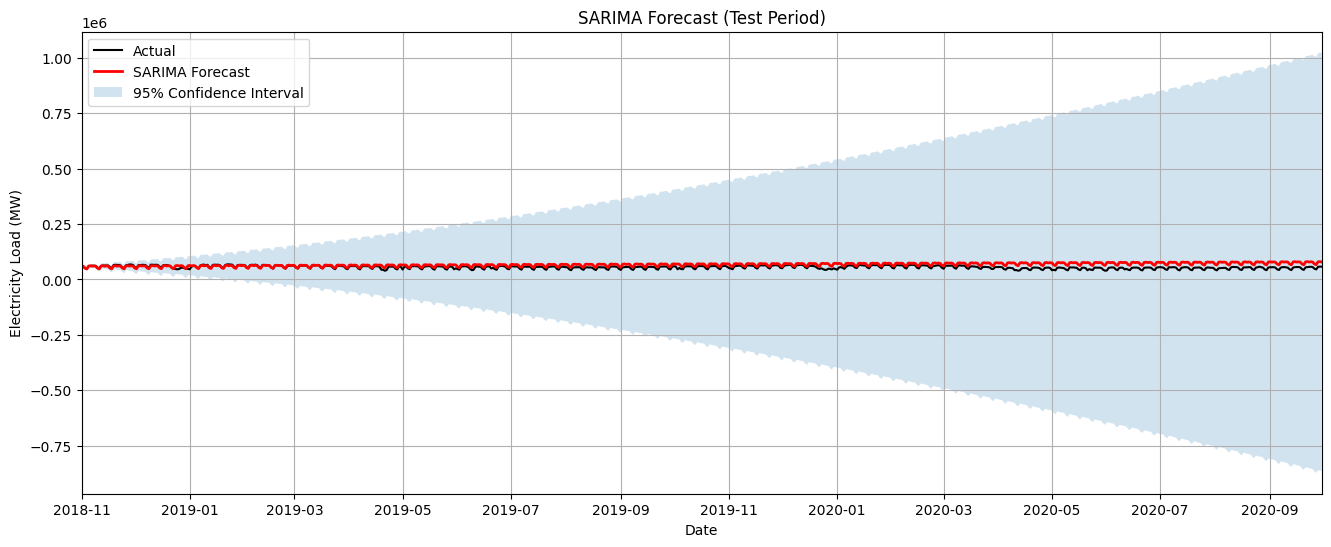

In [150]:
plt.figure(figsize=(16,6))

plt.plot(test.index, test.values,
         color="black",
         linewidth=1.5,
         label="Actual")

plt.plot(test.index, forecast_mean.values,
         color="red",
         linewidth=2,
         label="SARIMA Forecast")

plt.fill_between(
    test.index,
    confidence.iloc[:,0].values,
    confidence.iloc[:,1].values,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlim(test.index.min(), test.index.max())

plt.title("SARIMA Forecast (Test Period)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.savefig(
    "sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [151]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_mean
    )
)

print("RMSE =",rmse)

RMSE = 14731.130376560106


In [152]:
results = pd.DataFrame({

    "Model":["SARIMA"],

    "Order":[best_order],

    "RMSE":[rmse]

})

results

,Model,Order,RMSE
0,SARIMA,"(2, 1, 0)",14731.130377


In [153]:
print(train.index[:5])
print(test.index[:5])
print(forecast_mean.index[:5])

DatetimeIndex(['2015-01-01 00:00:00+00:00', '2015-01-02 00:00:00+00:00',
               '2015-01-03 00:00:00+00:00', '2015-01-04 00:00:00+00:00',
               '2015-01-05 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', freq='D')
DatetimeIndex(['2018-11-01 00:00:00+00:00', '2018-11-02 00:00:00+00:00',
               '2018-11-03 00:00:00+00:00', '2018-11-04 00:00:00+00:00',
               '2018-11-05 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', freq='D')
DatetimeIndex(['2018-11-01 00:00:00+00:00', '2018-11-02 00:00:00+00:00',
               '2018-11-03 00:00:00+00:00', '2018-11-04 00:00:00+00:00',
               '2018-11-05 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', freq='D')


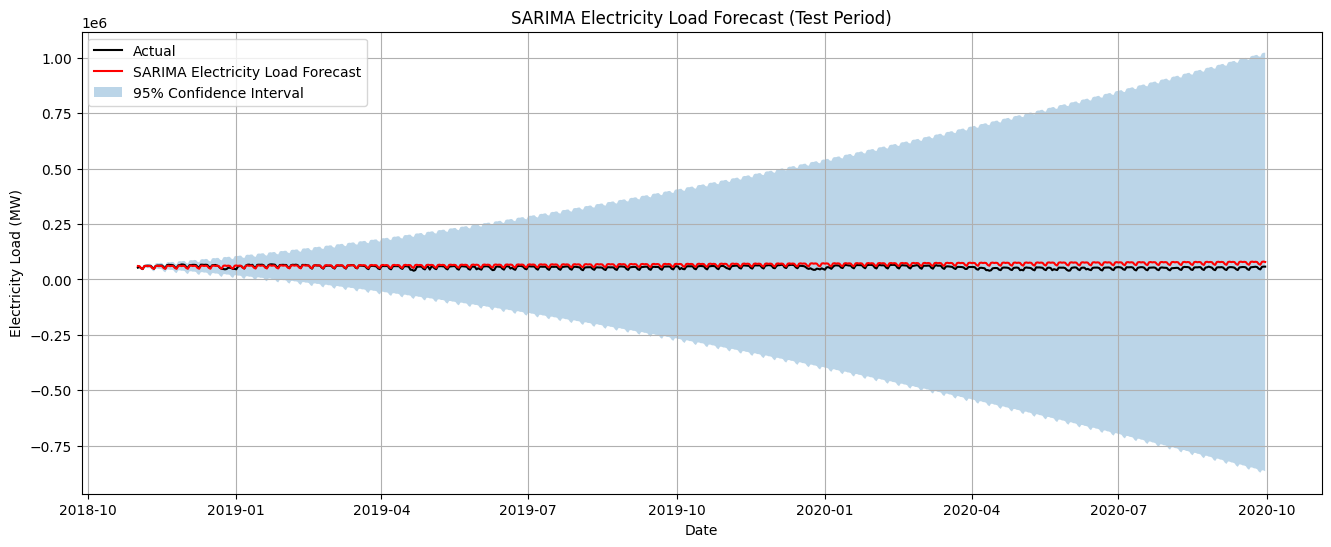

In [154]:
plt.figure(figsize=(16,6))

plt.plot(test, label="Actual", color="black")
plt.plot(forecast_mean, label="SARIMA Electricity Load Forecast", color="red")

plt.fill_between(
    test.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Electricity Load Forecast (Test Period)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [155]:
import pmdarima
print(pmdarima.__version__)

2.1.1


In [156]:
print(train.head())
print(train.tail())
print(test.head())

utc_timestamp
2015-01-01 00:00:00+00:00    45346.541667
2015-01-02 00:00:00+00:00    51941.166667
2015-01-03 00:00:00+00:00    46564.750000
2015-01-04 00:00:00+00:00    45082.500000
2015-01-05 00:00:00+00:00    55246.666667
Freq: D, Name: DE_load_actual_entsoe_transparency, dtype: float64
utc_timestamp
2018-10-27 00:00:00+00:00    51904.583333
2018-10-28 00:00:00+00:00    48619.791667
2018-10-29 00:00:00+00:00    62371.041667
2018-10-30 00:00:00+00:00    62840.250000
2018-10-31 00:00:00+00:00    58400.916667
Freq: D, Name: DE_load_actual_entsoe_transparency, dtype: float64
utc_timestamp
2018-11-01 00:00:00+00:00    53218.166667
2018-11-02 00:00:00+00:00    56623.041667
2018-11-03 00:00:00+00:00    50847.500000
2018-11-04 00:00:00+00:00    47122.208333
2018-11-05 00:00:00+00:00    59882.583333
Freq: D, Name: DE_load_actual_entsoe_transparency, dtype: float64


In [157]:
print(forecast_mean.head())
print(forecast_mean.tail())

utc_timestamp
2018-11-01 00:00:00+00:00    60576.168552
2018-11-02 00:00:00+00:00    59838.205538
2018-11-03 00:00:00+00:00    50732.611098
2018-11-04 00:00:00+00:00    47209.944282
2018-11-05 00:00:00+00:00    60253.176620
Freq: D, Name: predicted_mean, dtype: float64
utc_timestamp
2020-09-26 00:00:00+00:00    69911.662984
2020-09-27 00:00:00+00:00    66387.422024
2020-09-28 00:00:00+00:00    79371.532816
2020-09-29 00:00:00+00:00    80606.884951
2020-09-30 00:00:00+00:00    78832.683208
Freq: D, Name: predicted_mean, dtype: float64


In [158]:
print(confidence.head())

                           lower DE_load_actual_entsoe_transparency  \
utc_timestamp                                                         
2018-11-01 00:00:00+00:00                              55806.389862   
2018-11-02 00:00:00+00:00                              54006.009684   
2018-11-03 00:00:00+00:00                              44355.737331   
2018-11-04 00:00:00+00:00                              40091.401285   
2018-11-05 00:00:00+00:00                              52454.456773   

                           upper DE_load_actual_entsoe_transparency  
utc_timestamp                                                        
2018-11-01 00:00:00+00:00                              65345.947243  
2018-11-02 00:00:00+00:00                              65670.401391  
2018-11-03 00:00:00+00:00                              57109.484866  
2018-11-04 00:00:00+00:00                              54328.487279  
2018-11-05 00:00:00+00:00                              68051.896467  


In [159]:
print(daily_df["DE_load_actual_entsoe_transparency"].describe())

count     2100.000000
mean     55492.468552
std       6601.474342
min      38952.666667
25%      50413.447917
50%      56776.916667
75%      60430.093750
max      68183.583333
Name: DE_load_actual_entsoe_transparency, dtype: float64


**PART-4**

In [160]:
import requests
from math import sqrt

In [161]:
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52"
    "&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-10-31"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

response = requests.get(url)
weather = response.json()

temperature_df = pd.DataFrame({
    "Date": pd.to_datetime(weather["daily"]["time"]),
    "Temperature": weather["daily"]["temperature_2m_mean"]
})
temperature_df.to_csv("berlin_temperature_daily.csv")
temperature_df.set_index("Date", inplace=True)

temperature_df.head()

,Temperature
Date,
2015-01-01,2.6
2015-01-02,4.9
2015-01-03,3.8
2015-01-04,2.8
2015-01-05,2.9


In [162]:
weekly_temperature = temperature_df.resample("W").mean()

weekly_temperature.head()

,Temperature
Date,
2015-01-04,3.525000
2015-01-11,3.914286
2015-01-18,4.842857
2015-01-25,0.057143
2015-02-01,1.400000


In [163]:
weekly_load = df["DE_load_actual_entsoe_transparency"].resample("W").mean()

weekly_load = weekly_load.to_frame(name="Load")

weekly_load.head()

,Load
utc_timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


In [164]:
print(type(weekly_load))

<class 'pandas.core.frame.DataFrame'>


In [165]:
weekly_load.index = weekly_load.index.tz_localize(None)

In [166]:
weekly_data = weekly_load.join(
    weekly_temperature,
    how="inner"
)

weekly_data.dropna(inplace=True)

print(weekly_data.head())
print(weekly_data.shape)

                    Load  Temperature
2015-01-04  47233.739583     3.525000
2015-01-11  56191.101190     3.914286
2015-01-18  57672.678571     4.842857
2015-01-25  58613.303571     0.057143
2015-02-01  58734.029762     1.400000
(301, 2)


In [167]:
train = weekly_data.loc[:'2018-10-28']
test = weekly_data.loc['2018-11-04':]

print("Training weeks:", len(train))
print("Testing weeks:", len(test))

Training weeks: 200
Testing weeks: 101


In [168]:
train_y = train["Load"]
test_y = test["Load"]

train_x = train[["Temperature"]]
test_x = test[["Temperature"]]

In [203]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train_y,
    exog=train_x,
    order=(3,1,2),
    seasonal_order=(0,0,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit()

import pickle
import os

# Create the folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# Save the trained SARIMAX model
with open("saved_models/sarimax_model.pkl", "wb") as f:
    pickle.dump(sarimax_fit, f)

print("SARIMAX model saved successfully!")
print(sarimax_fit.summary())

SARIMAX model saved successfully!
                               SARIMAX Results                                
Dep. Variable:                   Load   No. Observations:                  200
Model:               SARIMAX(3, 1, 2)   Log Likelihood               -1768.511
Date:                Thu, 16 Jul 2026   AIC                           3551.022
Time:                        23:28:23   BIC                           3573.969
Sample:                    01-04-2015   HQIC                          3560.312
                         - 10-28-2018                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Temperature  -257.5026     40.798     -6.312      0.000    -337.464    -177.541
ar.L1           0.1091      0.312      0.350      0.727      -0.503       0.721
ar.L2         

In [170]:
forecast = sarimax_fit.get_forecast(
    steps=len(test),
    exog=test_x
)

forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

In [171]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(test_y, forecast_mean))

print("SARIMAX RMSE:", rmse)

SARIMAX RMSE: 3816.9880252562643


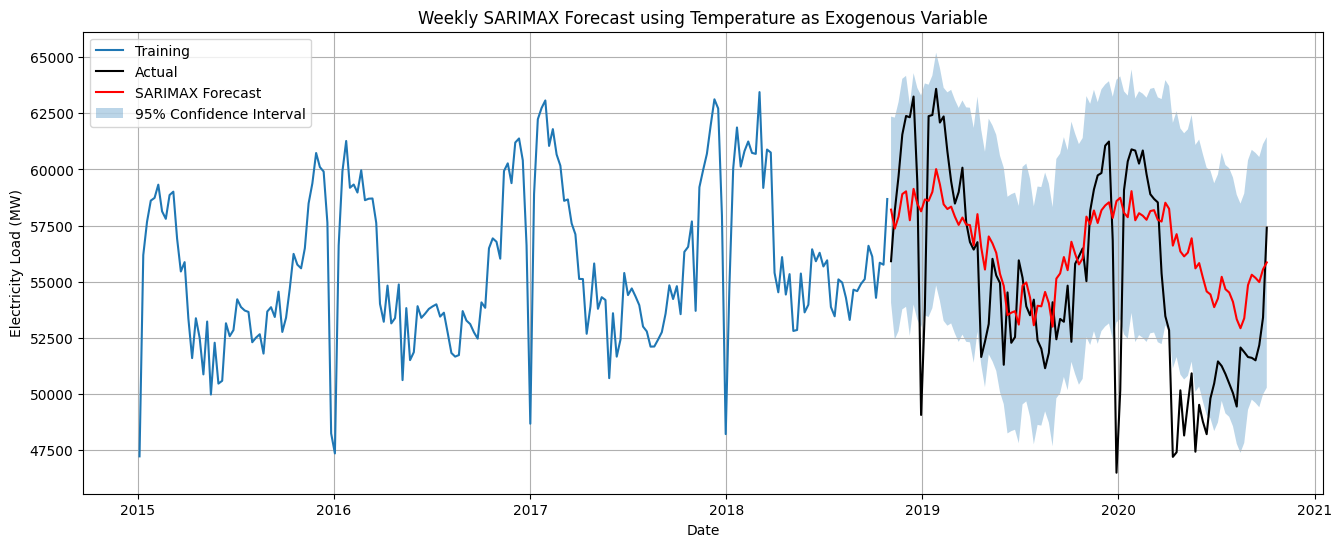

In [173]:
plt.figure(figsize=(16,6))

plt.plot(train.index, train_y, label="Training")
plt.plot(test.index, test_y, label="Actual", color="black")
plt.plot(test.index, forecast_mean, label="SARIMAX Forecast", color="red")

plt.fill_between(
    test.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Weekly SARIMAX Forecast using Temperature as Exogenous Variable")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.savefig(
    "sarimax_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [174]:
rmse = sqrt(mean_squared_error(test_y, forecast_mean))

print("Weekly SARIMAX RMSE:", rmse)

Weekly SARIMAX RMSE: 3816.9880252562643


**PART-5**

In [175]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

import matplotlib.pyplot as plt

In [176]:
weekly_ml = weekly_data.copy()

weekly_ml["Week"] = weekly_ml.index.isocalendar().week.astype(int)
weekly_ml["Month"] = weekly_ml.index.month
weekly_ml["Year"] = weekly_ml.index.year

weekly_ml.head()

,Load,Temperature,Week,Month,Year
2015-01-04,47233.739583,3.525000,1,1,2015
2015-01-11,56191.101190,3.914286,2,1,2015
2015-01-18,57672.678571,4.842857,3,1,2015
2015-01-25,58613.303571,0.057143,4,1,2015
2015-02-01,58734.029762,1.400000,5,2,2015


In [177]:
X = weekly_ml[["Temperature", "Week", "Month", "Year"]]

y = weekly_ml["Load"]

In [178]:
train_X = X.loc[:'2018-10-28']
test_X = X.loc['2018-11-04':]

train_y = y.loc[:'2018-10-28']
test_y = y.loc['2018-11-04':]

print(train_X.shape)
print(test_X.shape)

(200, 4)
(101, 4)


In [180]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(train_X, train_y)

RandomForestRegressor(n_estimators=200, random_state=42)

In [181]:
rf_forecast = rf.predict(test_X)

In [182]:
rmse = sqrt(mean_squared_error(test_y, rf_forecast))

print("Random Forest RMSE:", rmse)

Random Forest RMSE: 2951.928544624996


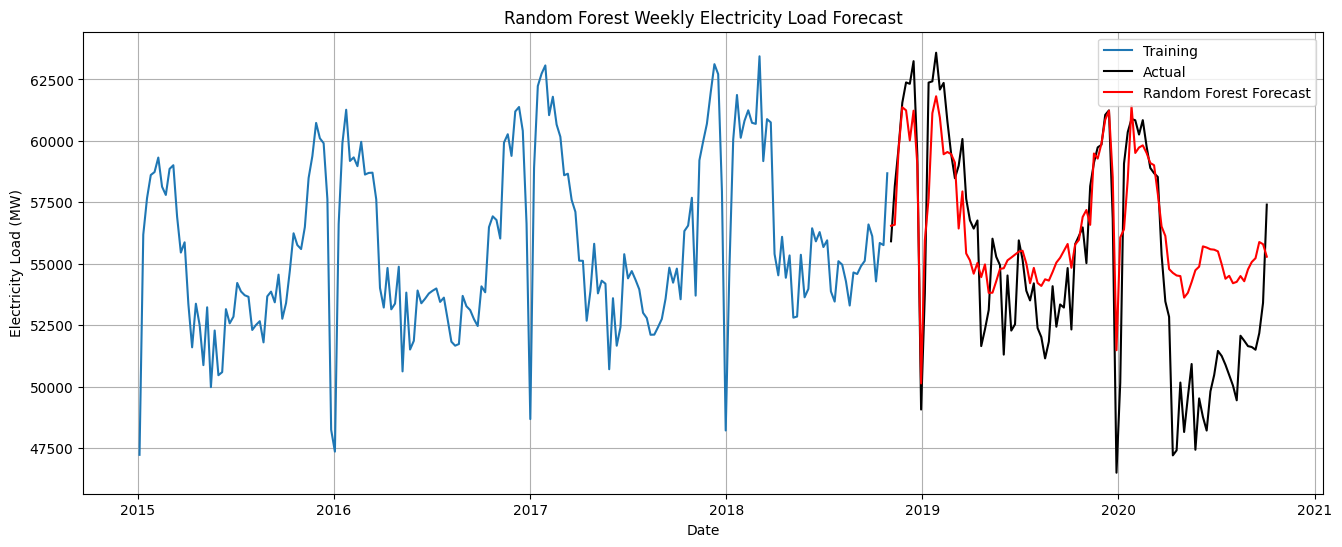

In [184]:
plt.figure(figsize=(16,6))

plt.plot(train_y.index, train_y,
         label="Training")

plt.plot(test_y.index, test_y,
         label="Actual",
         color="black")

plt.plot(test_y.index,
         rf_forecast,
         color="red",
         label="Random Forest Forecast")

plt.title("Random Forest Weekly Electricity Load Forecast")

plt.xlabel("Date")

plt.ylabel("Electricity Load (MW)")

plt.legend()

plt.grid(True)
plt.savefig(
    "random_forest_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [200]:
import joblib

joblib.dump(rf, "random_forest_model.joblib")

['random_forest_model.joblib']

**PART-6**

In [185]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [186]:
import keras

print(keras.__version__)

3.13.2


In [187]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Hourly German electricity load
hourly_series = (
    df["DE_load_actual_entsoe_transparency"]
    .dropna()
    .astype(float)
)

print(hourly_series.head())
print(hourly_series.shape)

utc_timestamp
2015-01-01 00:00:00+00:00    41151.0
2015-01-01 01:00:00+00:00    40135.0
2015-01-01 02:00:00+00:00    39106.0
2015-01-01 03:00:00+00:00    38765.0
2015-01-01 04:00:00+00:00    38941.0
Name: DE_load_actual_entsoe_transparency, dtype: float64
(50400,)


In [188]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(hourly_series.values.reshape(-1,1))

test_size = 24 * 365 * 2      # last 2 years = 17,520 hours

train_data = scaled_data[:-test_size]
test_data  = scaled_data[-test_size:]

print(train_data.shape)
print(test_data.shape)

(32880, 1)
(17520, 1)


In [189]:
sequence_length = 24

def create_sequences(data, seq_len):
    X = []
    y = []

    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i,0])
        y.append(data[i,0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

print(X_train.shape)
print(X_test.shape)

(32856, 24)
(17496, 24)


In [190]:
X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

X_test = X_test.reshape((X_test.shape[0],
                         X_test.shape[1],
                         1))

print(X_train.shape)
print(X_test.shape)

(32856, 24, 1)
(17496, 24, 1)


In [191]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        32,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [192]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - loss: 0.0213 - val_loss: 0.0038
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0058 - val_loss: 0.0020
Epoch 3/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 4/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 0.0022 - val_loss: 9.0016e-04
Epoch 5/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0018 - val_loss: 7.9460e-04
Epoch 6/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0016 - val_loss: 9.9797e-04
Epoch 7/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0015 - val_loss: 9.1487e-04
Epoch 8/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0013 - val_loss: 5.5270e-04
Epoch 9/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0013 - val_loss: 4.7259e-04
Epoch 10/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - loss: 0.0012 - val_loss: 5.3801e-04
Epoch 11/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0011 - val_loss: 6.5143e-0

In [193]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


In [194]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(actual, predictions))

print("LSTM RMSE:", rmse)

LSTM RMSE: 1094.9512296334822


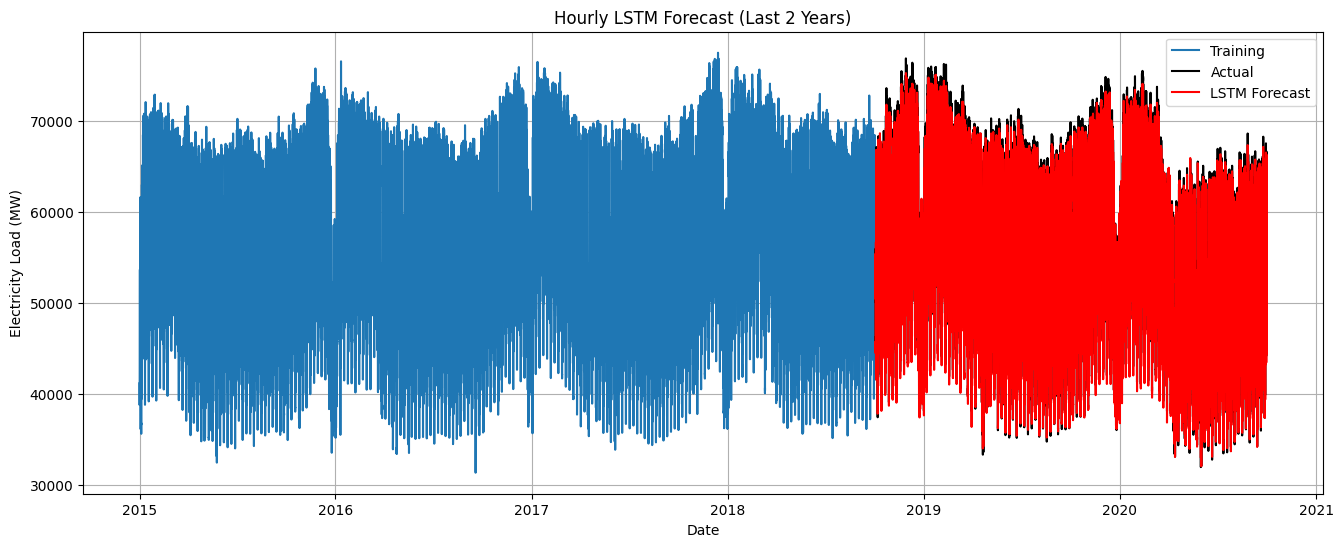

In [196]:
plt.figure(figsize=(16,6))

plt.plot(
    hourly_series.index[:-17520],
    hourly_series[:-17520],
    label="Training"
)

plt.plot(
    hourly_series.index[-17496:],
    actual,
    label="Actual",
    color="black"
)

plt.plot(
    hourly_series.index[-17496:],
    predictions,
    label="LSTM Forecast",
    color="red"
)

plt.title("Hourly LSTM Forecast (Last 2 Years)")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.savefig(
    "lstm_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [197]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

print("LSTM RMSE:", rmse)
print("LSTM MAE :", mae)

LSTM RMSE: 1094.9512296334822
LSTM MAE : 841.334894516068


In [198]:
from sklearn.metrics import r2_score

r2 = r2_score(actual, predictions)

print("LSTM R²:", r2)

LSTM R²: 0.9879798532304228


In [202]:
model.save("lstm_model.keras")